# Affinity & Embedding Comparison (R2)

Compares **PCA only**, **mean-PCA only**, **mean product**, and **BANKSY** for
capturing within-cell-type niche structure. `mean_product` (`rbf(own PCA) x
rbf(mean-neighbour PCA)`, per-space sigma) is the proposed affinity — COVET is
not used here.

kNN-based context uses **k=35** (~50 um) for the spatial mean/BANKSY context,
**k=50** for the affinity graphs.

| Method | Embedding | Affinity graph | What it encodes |
|---|---|---|---|
| PCA only | `X_pca` | `arbf_opt` | Transcriptomics only -- baseline |
| mean-PCA only | `X_mean_pca` | `ctx_mean` | RBF directly on the neighbourhood-averaged PCA (1st moment only, no own PCA) |
| mean product | -- (graph only) | `mean_product` (per-space sigma) | `rbf(own PCA) x rbf(mean-neighbour PCA)` -- soft AND logic between the two spaces |
| BANKSY | `X_banksy` | `banksy0.5` | `concat(own PCA, mean-neighbour PCA)` -> single RBF (first-order context, standard baseline) |

`mean_product` has no standalone feature space -- it's a product of two RBF
kernels, not a single embedding -- so it appears in the affinity-graph metrics
and (optionally) as a graph-built UMAP, but not in the embedding-space
silhouette comparison below.

**Two families of metrics, mirroring the two things R2 needs to show:**

1. **Affinity-graph metrics** (how the graph used for aggregation behaves):
   - `ct_weighted_purity` -- weighted fraction of affinity neighbors sharing the same **cell type**
   - `within_ct_niche_weighted_purity` -- same-cell-type neighbors only, weighted fraction sharing the same **niche**
2. **Embedding-space metrics** (how the raw feature space itself separates labels -- the silhouette/kNN-purity quantification R2 calls for):
   - `ct_silhouette` -- silhouette score of cell-type clusters in the embedding
   - `within_ct_niche_silhouette` -- mean (size-weighted) silhouette of niche labels, computed within each cell type

## Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -q scarches SEACells faiss-gpu-cu12 scib-metrics

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 919.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.4 MB/s eta 

In [5]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py

nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


## Config -- set these for your dataset

In [6]:
import os

DATA_PATH = os.path.join(os.environ['DATA_DIR'], 'spatial/NSCLC_3D_section_28.h5ad')
GRAPH_DIR = os.path.join(os.environ['CODE_DIR'], 'graphs')
DS_NAME   = 'NSCLC_3D_section_28'   # used in affinity filenames
CT_KEY    = 'celltypes'
NICHE_KEY = 'niches_2D'
K_AFF     = 50                       # affinity graph kNN
K_CTX     = 35                       # spatial neighbours for mean-PCA / BANKSY context (~50 um)


## Load & preprocess

In [7]:
import scanpy as sc
import numpy as np

ad = sc.read_h5ad(DATA_PATH)
print(ad)
print('obs columns:', ad.obs.columns.tolist())
print('obsm keys:  ', list(ad.obsm.keys()))
print(f'\ncell types ({ad.obs[CT_KEY].nunique()}):', sorted(ad.obs[CT_KEY].unique()))
print(f'niches ({ad.obs[NICHE_KEY].nunique()}):', sorted(ad.obs[NICHE_KEY].dropna().unique()))

AnnData object with n_obs × n_vars = 58423 × 960
    obs: 'section', 'celltypes', 'niches_3D', 'niches_2D', 'fibroblast_subclusters', 'tumor_pseudotime_rank', 'EMT_niche'
    uns: 'EMT_niche_colors', 'celltypes_colors', 'fibroblast_subclusters_colors', 'log1p', 'niches_2D_colors', 'niches_3D_colors', 'pca'
    obsm: 'X_covet', 'X_pca', 'X_umap_2D_neighbourhoods', 'X_umap_3D_neighbourhoods', 'X_umap_SCT', 'spatial'
    varm: 'PCs'
    layers: 'SCT', 'counts'
obs columns: ['section', 'celltypes', 'niches_3D', 'niches_2D', 'fibroblast_subclusters', 'tumor_pseudotime_rank', 'EMT_niche']
obsm keys:   ['X_covet', 'X_pca', 'X_umap_2D_neighbourhoods', 'X_umap_3D_neighbourhoods', 'X_umap_SCT', 'spatial']

cell types (18): ['Alveolar cells', 'B cells', 'Basal epithelial cells', 'Cycling immune cells', 'Cytotoxic T cells', 'Dendritic cells', 'Fibroblasts', 'Lymphatic endothelial cells', 'Macrophages', 'Mast cells', 'Monocytes', 'Pericytes', 'Plasma cells', 'Regulatory T cells', 'Respiratory epith

In [8]:
if 'X_pca' not in ad.obsm:
    sc.pp.highly_variable_genes(ad, n_top_genes=2000)
    sc.tl.pca(ad, n_comps=50, use_highly_variable=True)
    print('PCA computed:', ad.obsm['X_pca'].shape)
else:
    print('X_pca already present:', ad.obsm['X_pca'].shape)

X_pca already present: (58423, 50)


## Generate and save affinity graphs

Each cell runs independently -- skip any you've already computed. Only the
per-space-sigma variant of `mean_product` is kept (sigma-union was a looser
ablation of the same method, not a separate baseline worth reporting).

In [9]:
from interpretable_ssl.augmenters.graph_generator import generate_affinity, save_affinity

# PCA only -- transcriptomics-only baseline
aff_pca = generate_affinity(ad, k=K_AFF, bk=None, affinity_type='arbf_opt')
aff_pca.setdiag(0)
aff_pca.eliminate_zeros()
save_affinity(aff_pca, DS_NAME, len(ad), affinity_type='arbf_opt',
              k_neighbors=K_AFF, graph_dir=GRAPH_DIR)

arbf_opt
arbf_opt: recalculating PCA (n_comps=50) then optimized rbf ...
[rbf_optimized] n=58423  k=50  build_on=X_pca  graph_construction=union
[rbf_optimized] feature stats: shape=(58423, 50)  min=-1.9677e+01  mean=1.9889e+00  max=3.2125e+01  std=3.0460e+00
[rbf_optimized] step 1-4: kNN → sigma → sym ...
[rbf_optimized] sym nnz=4700191  nnz/row=80.5  sigma min=6.4085e+00  mean=1.4497e+01  max=2.0480e+01
[rbf_optimized] step 5: computing RBF ...
[rbf_optimized] done  M.nnz=4700191  rbf min=7.9388e-02  mean=3.4309e-01  max=1.0000e+00
Saved: /content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_arbf_opt.pkl


'/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_arbf_opt.pkl'

In [10]:
# mean-PCA only -- RBF applied directly to the spatially-averaged PCA (1st moment, no own PCA).
# Built directly (not via the 'ctx_mean' affinity_type, which hardcodes k=100 -- a COVET-era
# context radius) so this shares the same k=35 (~50 um) context as mean_product and BANKSY below.
from interpretable_ssl.augmenters.graph_generator import compute_mean_pca_context, rbf_optimized

if 'X_mean_pca' not in ad.obsm:
    compute_mean_pca_context(ad, k=K_CTX, obsm_key='X_mean_pca')

aff_meanpca = rbf_optimized(ad, build_on='X_mean_pca', k=K_AFF, graph_construction='union')
aff_meanpca.setdiag(0)
aff_meanpca.eliminate_zeros()
save_affinity(aff_meanpca, DS_NAME, len(ad), affinity_type='mean_pca_only',
              k_neighbors=K_AFF, graph_dir=GRAPH_DIR)

compute_mean_pca_context: k=35  dims=50  V=116.121  mode=plain avg
[rbf_optimized] n=58423  k=50  build_on=X_mean_pca  graph_construction=union
[rbf_optimized] feature stats: shape=(58423, 50)  min=-1.4943e+01  mean=7.6172e-01  max=2.4391e+01  std=1.5241e+00
[rbf_optimized] step 1-4: kNN → sigma → sym ...
[rbf_optimized] sym nnz=3731491  nnz/row=63.9  sigma min=1.1713e+00  mean=3.7847e+00  max=6.1873e+00
[rbf_optimized] step 5: computing RBF ...
[rbf_optimized] done  M.nnz=3731491  rbf min=1.4684e-03  mean=3.8220e-01  max=1.0000e+00
Saved: /content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_mean_pca_only.pkl


'/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_mean_pca_only.pkl'

In [11]:
# mean product -- rbf(own PCA) x rbf(mean-neighbour PCA), per-space sigma only
aff_mp = generate_affinity(ad, k=K_AFF, bk=None, affinity_type='mean_product',
                           per_space_sigma=True)
aff_mp.setdiag(0)
aff_mp.eliminate_zeros()
save_affinity(aff_mp, DS_NAME, len(ad), affinity_type='mean_product_pss',
              k_neighbors=K_AFF, graph_dir=GRAPH_DIR)

mean_product
[generate_affinity] mean_product: feature_k=35  aff_k=50  weight=rbf_pca×rbf_mean_pca  per_space_sigma=True  weighted_context=False
compute_mean_pca_context: k=35  dims=50  V=116.121  mode=plain avg
[rbf_product] n=58423  k=50  spaces=['X_pca', 'X_mean_pca']
[rbf_product] step 1.1: kNN → sym  X_pca  (sc.pp.neighbors) ...
[rbf_product] step 1.1 done (36.3s)  nnz=4700191  nnz/row=80.5
[rbf_product] step 1.2: kNN → sym  X_mean_pca  (sc.pp.neighbors) ...
[rbf_product] step 1.2 done (30.4s)  nnz=3731491  nnz/row=63.9
[rbf_product] step 2: union done (0.2s)  nnz=8303655  nnz/row=142.1
[rbf_product] step 3: RBF product over 2 spaces  sigma=per-space (own kNN) ...
[rbf_product]   X_pca: sigma [6.408e+00, 1.450e+01, 2.048e+01]
[rbf_product]   X_mean_pca: sigma [1.171e+00, 3.785e+00, 6.187e+00]
[rbf_product] step 3 done (16.3s)  nnz=8303655
[rbf_product] step 4: top-50 pruning per row + re-symmetrize ...
[rbf_product] step 4 done (1.3s)  nnz=3414094 (was 8303655, 59% removed)  nnz/r

'/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_mean_product_pss.pkl'

In [12]:
# BANKSY -- concat(own PCA, mean-neighbour PCA) -> single RBF (alpha=0.5, equal balance)
aff_banksy = generate_affinity(ad, k=K_AFF, bk=None, affinity_type='banksy0.5')
aff_banksy.setdiag(0)
aff_banksy.eliminate_zeros()
save_affinity(aff_banksy, DS_NAME, len(ad), affinity_type='banksy0.5',
              k_neighbors=K_AFF, graph_dir=GRAPH_DIR)

banksy0.5
banksy: alpha=0.50  V_pca=463.919  V_ctx=116.121  lambda=0.894  weighted_context=False
  [build_seacell_kernel] n=58423  k=50  x_graph.shape=(58423, 100)  X_aff.shape=(58423, 100)  symmetrize=False
  [build_seacell_kernel] kNN done in 47.0s  idxs.shape=(58423, 50)  (self excluded)
  [build_seacell_kernel] RBF done in 2.3s  A_vals min=0.1306  max=0.8568  mean=0.3598
  [build_seacell_kernel] sparse matrix built  nnz=2921150  nnz_per_row=50.0
Saved: /content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_banksy0.5.pkl


'/content/drive/MyDrive/codes/interpretable-prototype/graphs/affinity_NSCLC_3D_section_2858423_ncomp50_kneighbors50_banksy0.5.pkl'

## Compute affinity-graph metrics

Load saved affinities (or reuse in-memory ones if they're still in scope).

In [13]:
import pickle, os
from interpretable_ssl.configs.paths import get_affinity_path

def load_aff(affinity_type):
    path = get_affinity_path(DS_NAME, len(ad), k_neighbors=K_AFF,
                             affinity_type=affinity_type, graph_dir=GRAPH_DIR)
    with open(path, 'rb') as f:
        return pickle.load(f)

affinities = {
    'PCA only'      : load_aff('arbf_opt'),
    'mean-PCA only' : load_aff('mean_pca_only'),
    'mean product'  : load_aff('mean_product_pss'),
    'BANKSY'        : load_aff('banksy0.5'),
}

In [14]:
from interpretable_ssl.evaluation.metric_helpers.affinity_metrics import compare_affinities

ct_labels    = ad.obs[CT_KEY].astype(str).values
niche_labels = ad.obs[NICHE_KEY].astype(str).replace('nan', 'Unknown').values

aff_results = compare_affinities(affinities, ct_labels, niche_labels)
print(aff_results.round(4))

               ct_weighted_purity  within_ct_niche_weighted_purity
PCA only                   0.7656                           0.3595
mean-PCA only              0.3432                           0.7556
mean product               0.5990                           0.7163
BANKSY                     0.7439                           0.6068


## Visualize -- affinity-graph metrics

### Trade-off scatter (hero figure)

x = cell-type weighted purity, y = within-CT niche weighted purity.
Top-right corner = best of both worlds.

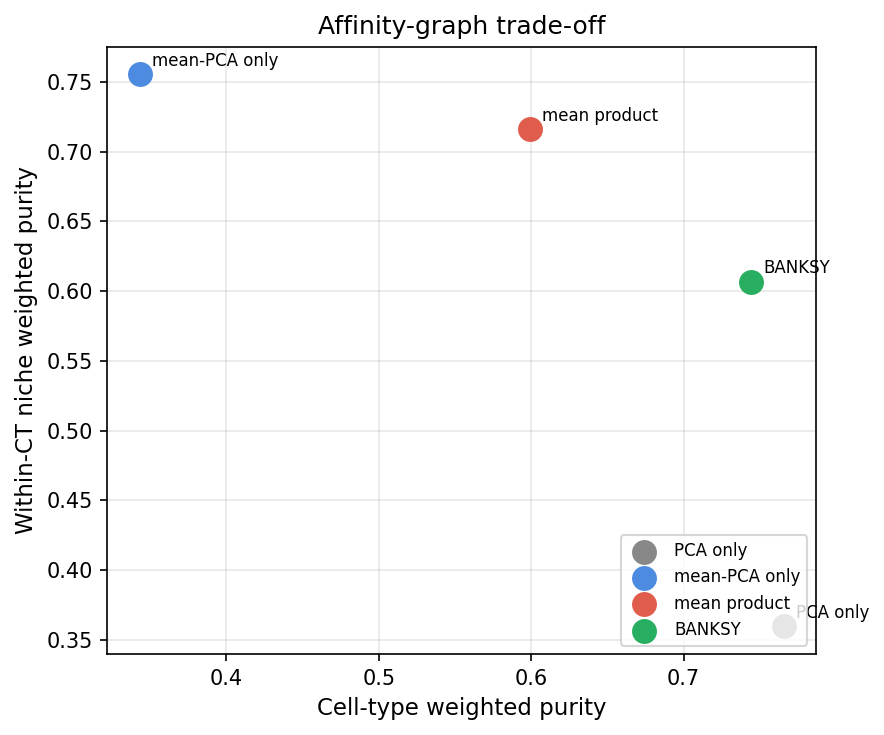

In [15]:
import matplotlib.pyplot as plt

colors = {
    'PCA only'      : '#888888',
    'mean-PCA only' : '#4C8BE0',
    'mean product'  : '#E05C4C',
    'BANKSY'        : '#27AE60',
}

fig, ax = plt.subplots(figsize=(6, 5))
for method, row in aff_results.iterrows():
    ax.scatter(row['ct_weighted_purity'], row['within_ct_niche_weighted_purity'],
               color=colors.get(method, 'black'), s=120, zorder=3, label=method)
    ax.annotate(method, (row['ct_weighted_purity'], row['within_ct_niche_weighted_purity']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_xlabel('Cell-type weighted purity', fontsize=11)
ax.set_ylabel('Within-CT niche weighted purity', fontsize=11)
ax.set_title('Affinity-graph trade-off', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'r2_affinity_tradeoff.pdf'), bbox_inches='tight')
plt.show()

### Bar charts

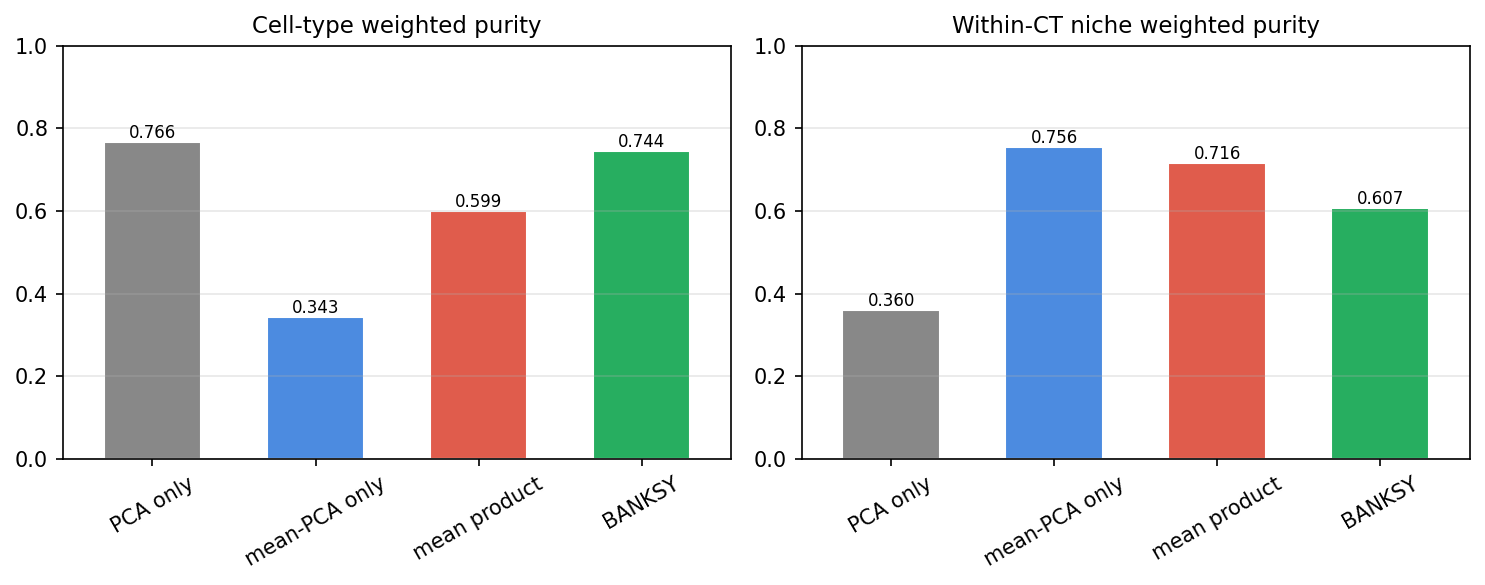

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title in zip(
    axes,
    ['ct_weighted_purity', 'within_ct_niche_weighted_purity'],
    ['Cell-type weighted purity', 'Within-CT niche weighted purity'],
):
    bar_colors = [colors.get(m, 'steelblue') for m in aff_results.index]
    aff_results[col].plot(kind='bar', ax=ax, color=bar_colors, edgecolor='white', width=0.6)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'r2_affinity_bars.pdf'), bbox_inches='tight')
plt.show()

### Per-cell-type breakdown

Which cell types benefit most from niche-aware (context-informed) affinity?

In [17]:
from interpretable_ssl.evaluation.metric_helpers.affinity_metrics import weighted_purity_within_group
import pandas as pd

REF_METHOD = 'mean product'   # column used to sort the heatmap/table

per_ct = {}
for method, aff in affinities.items():
    per_cell = weighted_purity_within_group(aff, ct_labels, niche_labels)
    df = ad.obs[[CT_KEY]].copy()
    df['niche_purity'] = per_cell
    per_ct[method] = df.groupby(CT_KEY)['niche_purity'].mean()

per_ct_df = pd.DataFrame(per_ct)
print(per_ct_df.round(3).sort_values(REF_METHOD, ascending=False))

                             PCA only  mean-PCA only  mean product  BANKSY
celltypes                                                                 
Respiratory epithelium          0.962          0.996         0.992   0.985
Basal epithelial cells          0.918          0.989         0.984   0.978
Pericytes                       0.519          0.866         0.801   0.697
Dendritic cells                 0.361          0.859         0.792   0.640
Smooth muscle cells             0.436          0.814         0.774   0.651
Alveolar cells                  0.597          0.805         0.765   0.699
Vascular endothelium            0.408          0.825         0.764   0.630
Lymphatic endothelial cells     0.412          0.819         0.734   0.579
Cytotoxic T cells               0.273          0.754         0.716   0.557
Plasma cells                    0.395          0.777         0.701   0.579
Tumor cells                     0.413          0.727         0.701   0.640
Macrophages              

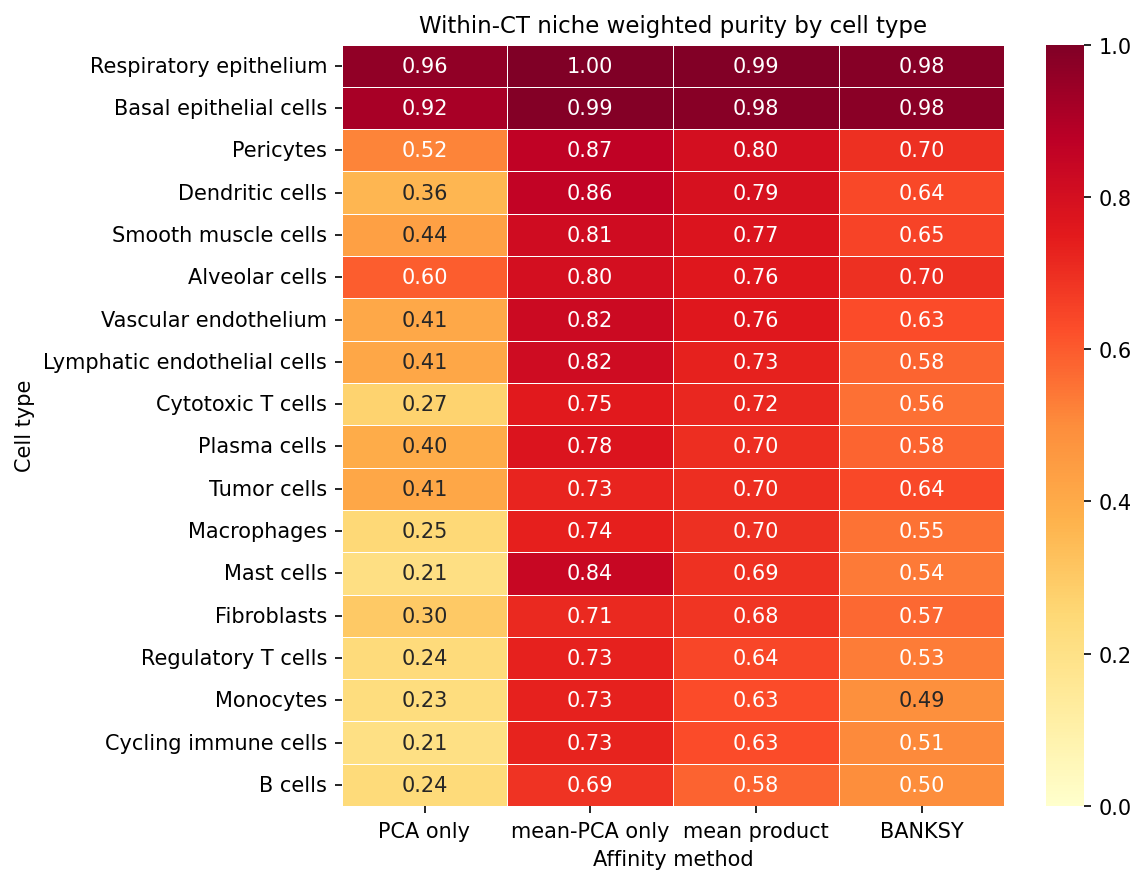

In [18]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    per_ct_df.sort_values(REF_METHOD, ascending=False),
    annot=True, fmt='.2f', cmap='YlOrRd',
    vmin=0, vmax=1, ax=ax, linewidths=0.4,
)
ax.set_title('Within-CT niche weighted purity by cell type', fontsize=11)
ax.set_xlabel('Affinity method')
ax.set_ylabel('Cell type')
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'r2_affinity_per_ct_heatmap.pdf'), bbox_inches='tight')
plt.show()

## Embedding-space quantification

R2 asks for a silhouette-score (or kNN-purity) comparison computed directly in
each **embedding space**, not the derived affinity graph. `mean_product` has no
standalone embedding (see header), so this section covers the three feature
spaces that do: `X_pca`, `X_mean_pca`, `X_banksy`.

In [19]:
from interpretable_ssl.augmenters.graph_generator import compute_mean_pca_context

if 'X_mean_pca' not in ad.obsm:
    compute_mean_pca_context(ad, k=K_CTX, obsm_key='X_mean_pca')
# X_banksy was already populated as a side effect of generating the BANKSY affinity above
assert 'X_banksy' in ad.obsm, "run the BANKSY affinity-generation cell first"

embeddings = {
    'PCA'      : ad.obsm['X_pca'],
    'mean-PCA' : ad.obsm['X_mean_pca'],
    'BANKSY'   : ad.obsm['X_banksy'],
}

In [20]:
from interpretable_ssl.evaluation.metric_helpers.affinity_metrics import compare_embeddings

emb_results = compare_embeddings(embeddings, ct_labels, niche_labels, sample_size=5000, random_state=0)
print(emb_results.round(4))

          ct_silhouette  within_ct_niche_silhouette
PCA              0.0622                     -0.0327
mean-PCA        -0.0794                      0.0303
BANKSY           0.0250                      0.0159


### Trade-off scatter -- embedding space

x = cell-type silhouette, y = within-CT niche silhouette (both computed on raw
embedding coordinates). Top-right corner = best of both worlds.

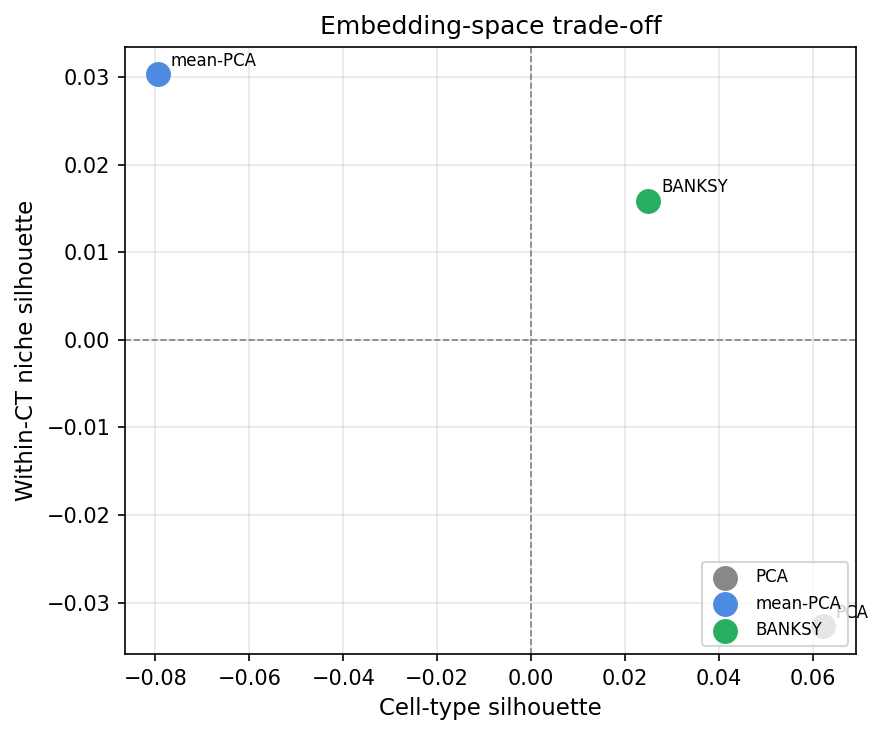

In [21]:
emb_colors = {'PCA': '#888888', 'mean-PCA': '#4C8BE0', 'BANKSY': '#27AE60'}

fig, ax = plt.subplots(figsize=(6, 5))
for emb, row in emb_results.iterrows():
    ax.scatter(row['ct_silhouette'], row['within_ct_niche_silhouette'],
               color=emb_colors.get(emb, 'black'), s=120, zorder=3, label=emb)
    ax.annotate(emb, (row['ct_silhouette'], row['within_ct_niche_silhouette']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_xlabel('Cell-type silhouette', fontsize=11)
ax.set_ylabel('Within-CT niche silhouette', fontsize=11)
ax.set_title('Embedding-space trade-off', fontsize=12)
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'r2_embedding_silhouette_tradeoff.pdf'), bbox_inches='tight')
plt.show()

### Bar charts -- embedding-space silhouette

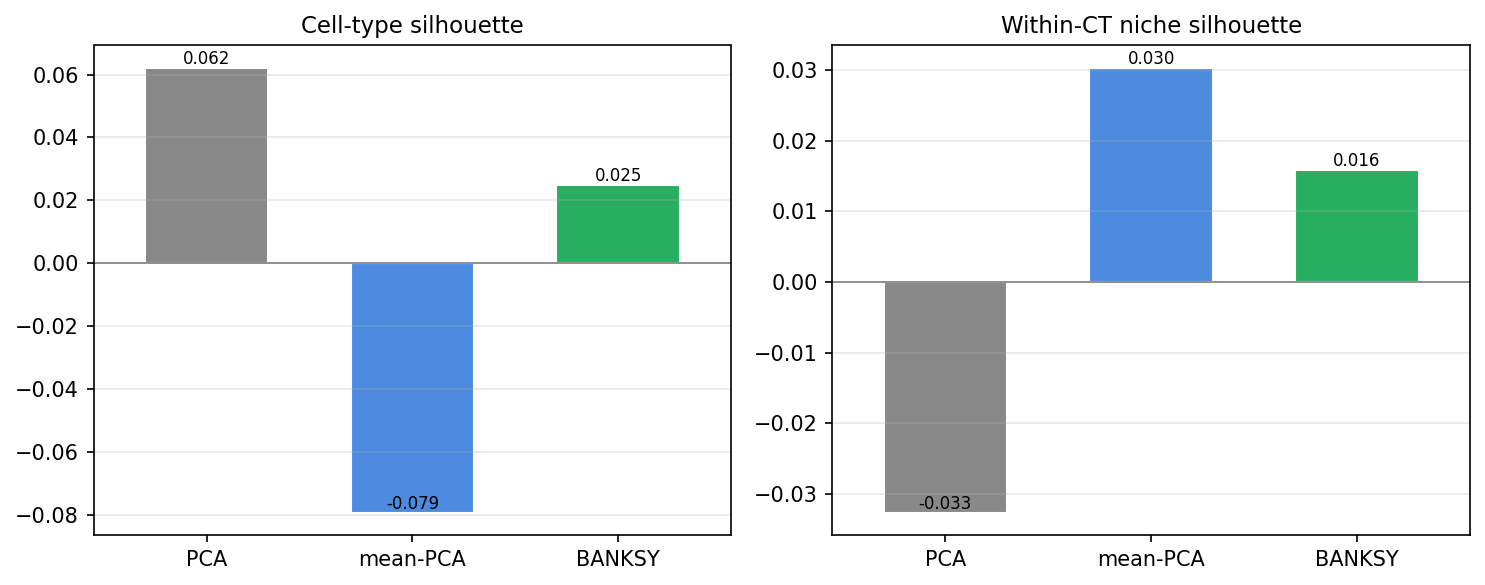

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title in zip(
    axes,
    ['ct_silhouette', 'within_ct_niche_silhouette'],
    ['Cell-type silhouette', 'Within-CT niche silhouette'],
):
    bar_colors = [emb_colors.get(m, 'steelblue') for m in emb_results.index]
    emb_results[col].plot(kind='bar', ax=ax, color=bar_colors, edgecolor='white', width=0.6)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='gray', lw=0.8)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'r2_embedding_silhouette_bars.pdf'), bbox_inches='tight')
plt.show()

### UMAP of each embedding

Colored by cell type and by niche -- shows what structure each *feature space*
sees. `mean_product` has no standalone feature space, so it's approximated
here by building a UMAP directly from its precomputed affinity graph (rather
than from embedding coordinates) -- purely for visual reference, since the
quantitative comparison above already covers it via the affinity-graph
metrics.

In [23]:
embeddings_for_umap = {
    'PCA'       : 'X_pca',
    'mean_pca'  : 'X_mean_pca',
    'BANKSY'    : 'X_banksy',
}

for label, key in embeddings_for_umap.items():
    sc.pp.neighbors(ad, use_rep=key, n_neighbors=30, key_added=f'neighbors_{label}')
    sc.tl.umap(ad, neighbors_key=f'neighbors_{label}', min_dist=0.3)
    ad.obsm[f'X_umap_{label}'] = ad.obsm['X_umap'].copy()
    print(f'UMAP done: {label}')

UMAP done: PCA
UMAP done: mean_pca
UMAP done: BANKSY


In [24]:
# Bonus: UMAP built directly from the mean_product affinity graph (no standalone embedding).
# Wrapped in try/except -- purely illustrative, not required for the quantitative comparison.
try:
    mp_key = 'mean_product_graph'
    conn = affinities['mean product'].tocsr()
    ad.obsp[f'{mp_key}_connectivities'] = conn
    ad.obsp[f'{mp_key}_distances'] = conn
    ad.uns[mp_key] = {
        'connectivities_key': f'{mp_key}_connectivities',
        'distances_key': f'{mp_key}_distances',
        'params': {'n_neighbors': K_AFF, 'method': 'umap'},
    }
    sc.tl.umap(ad, neighbors_key=mp_key, min_dist=0.3)
    ad.obsm['X_umap_mean_product'] = ad.obsm['X_umap'].copy()
    embeddings_for_umap['mean_product (graph)'] = None  # marker: use precomputed X_umap_mean_product
    print('UMAP done: mean_product (from affinity graph)')
except Exception as e:
    print(f'Skipping mean_product graph-UMAP ({e}) -- quantitative comparison above is unaffected.')

UMAP done: mean_product (from affinity graph)


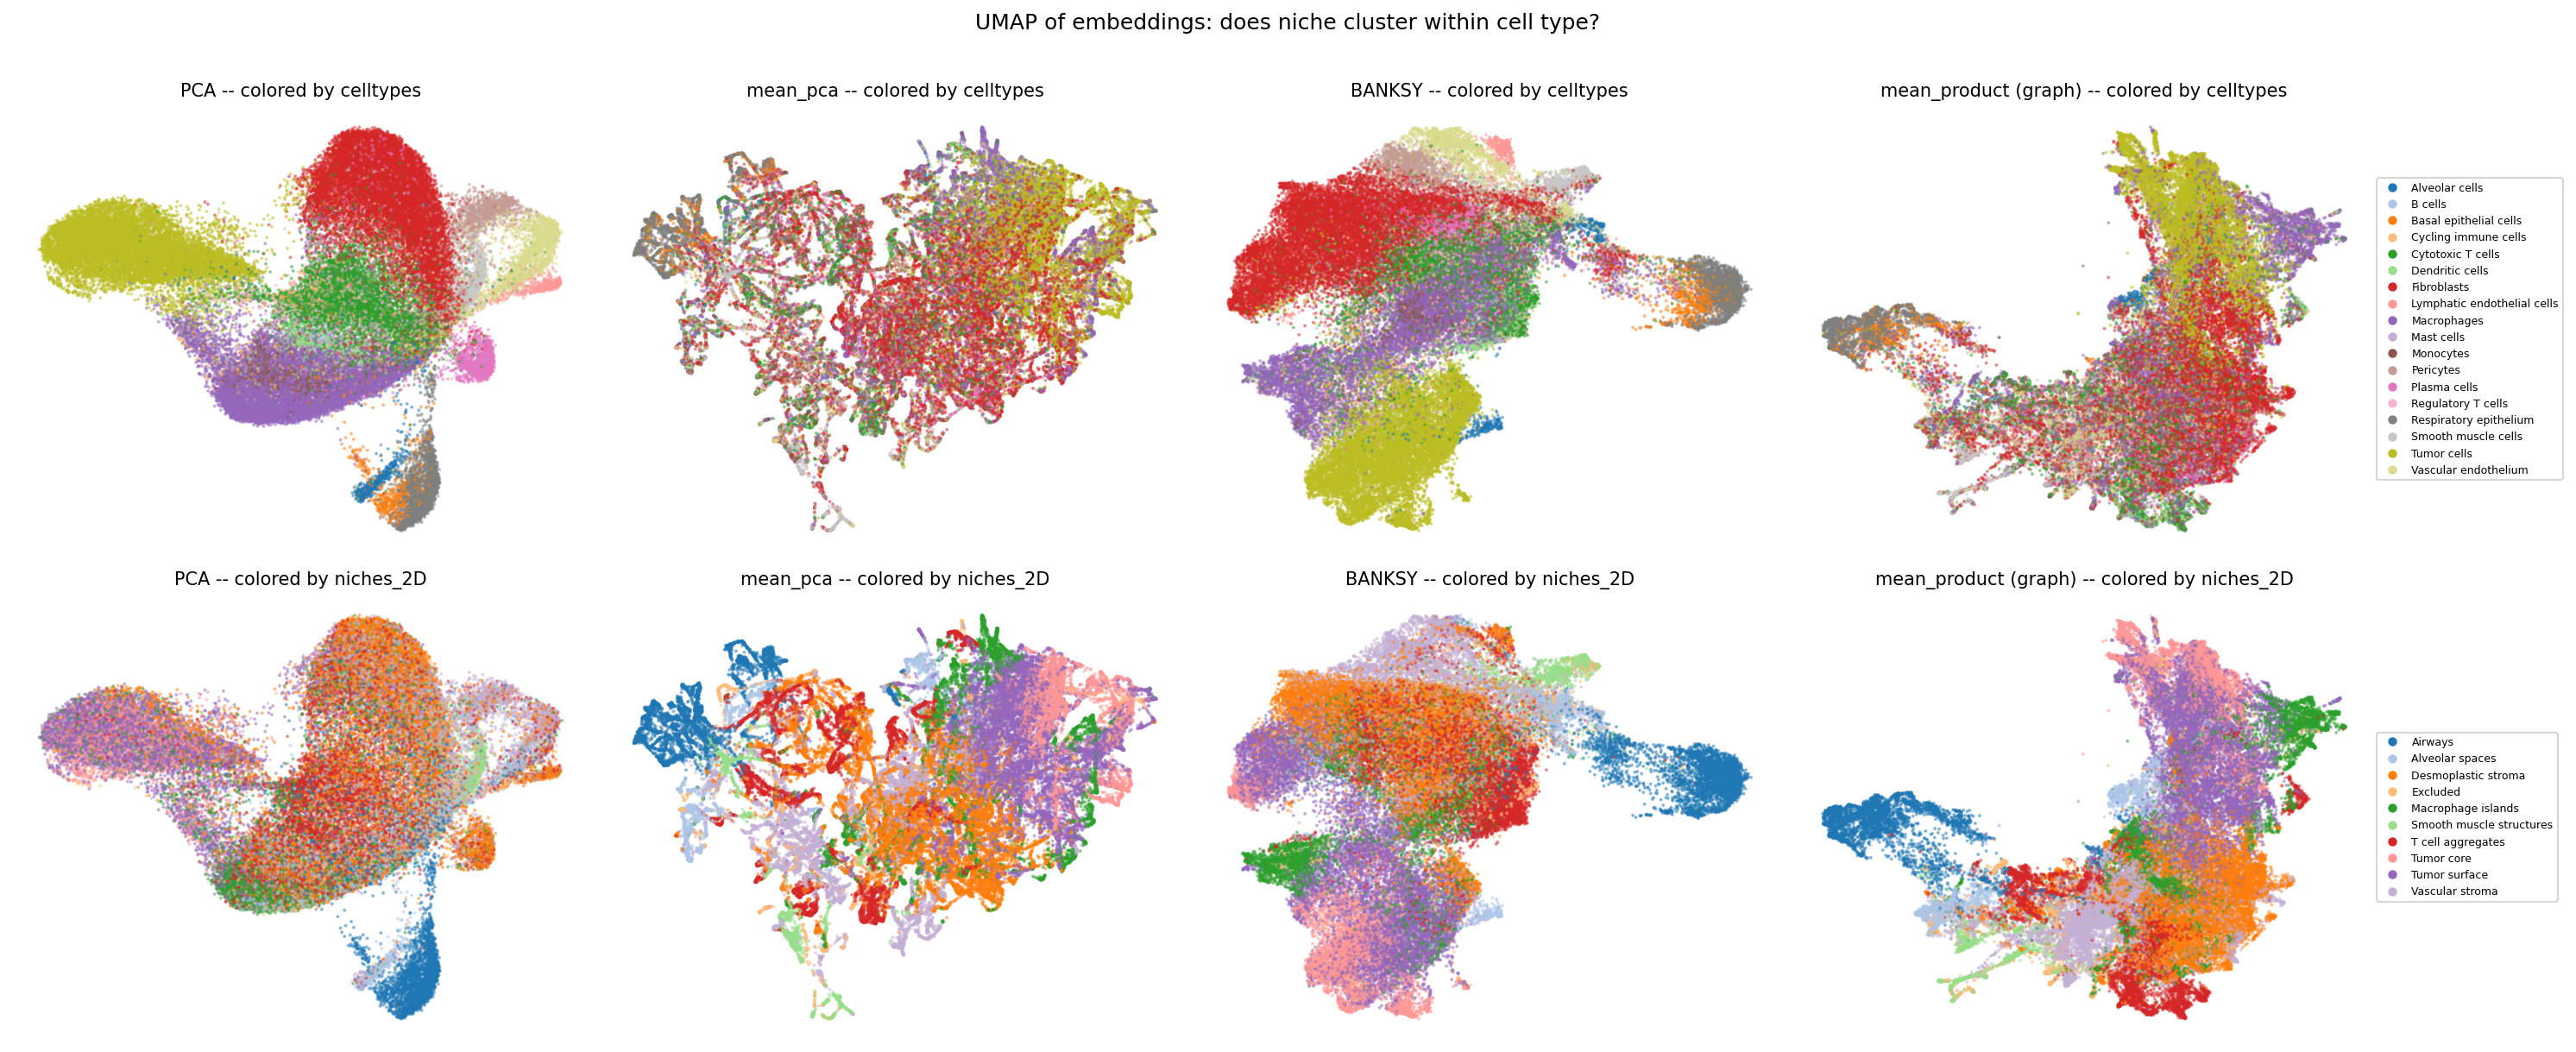

In [25]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

color_keys = [CT_KEY, NICHE_KEY]
emb_labels = list(embeddings_for_umap.keys())
n_rows = len(color_keys)
n_cols = len(emb_labels)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for row_i, ck in enumerate(color_keys):
    categories = ad.obs[ck].astype('category').cat.categories
    palette = plt.cm.tab20.colors
    color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(categories)}
    cell_colors = [color_map[c] for c in ad.obs[ck].astype(str)]

    for col_i, emb_label in enumerate(emb_labels):
        ax = axes[row_i][col_i]
        umap_key = 'X_umap_mean_product' if emb_label == 'mean_product (graph)' else f'X_umap_{emb_label}'
        X_umap = ad.obsm[umap_key]
        ax.scatter(X_umap[:, 0], X_umap[:, 1],
                   c=cell_colors, s=1, alpha=0.4, rasterized=True)
        ax.set_title(f'{emb_label} -- colored by {ck}', fontsize=10)
        ax.axis('off')

    handles = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[c], markersize=6, label=c)
               for c in categories]
    axes[row_i][-1].legend(handles=handles, fontsize=6,
                            loc='center left', bbox_to_anchor=(1, 0.5),
                            ncol=max(1, len(categories) // 20))

plt.suptitle('UMAP of embeddings: does niche cluster within cell type?', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, 'r2_affinity_umap_comparison.pdf'),
            bbox_inches='tight', dpi=150)
plt.show()